## Setup

In [1]:
import sys
sys.path.insert(0, "../../src/python/")

In [2]:
import os
import pickle
import warnings
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.models import efficientnet_b3
from torchvision.models import EfficientNet_B3_Weights

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [3]:
# TRAIN_IMAGE_DIR = "/mnt/d/skin-lesion-data/final-data/train/"
# TRAIN_LABEL_FILE = "/mnt/d/skin-lesion-data/final-data/labels/mappings.pkl"

# VAL_IMAGE_DIR = "/mnt/d/skin-lesion-data/final-data/test"
# VAL_LABEL_FILE = "/mnt/d/skin-lesion-data/final-data/test_labels/mappings_test.pkl"

TRAIN_IMAGE_DIR = "/home/shadeform/data/train/"
TRAIN_LABEL_FILE = "/home/shadeform/data/labels/mappings.pkl"

VAL_IMAGE_DIR = "/home/shadeform/data/test/"
VAL_LABEL_FILE = "/home/shadeform/data/labels/mappings_test.pkl"

## Binary Classification Model Configurations

In [4]:
with open(TRAIN_LABEL_FILE, "rb") as f:
    train_labels = pickle.load(f)

with open(VAL_LABEL_FILE, "rb") as f:
    val_labels = pickle.load(f)

print(len(train_labels), len(val_labels))

30931 8238


In [5]:
BINARY_MAP = {"NV": 0, "BKL": 0, "DF": 0, "VASC": 0, "MEL": 1, "BCC": 1, "AK": 1, "SCC": 1}
BENIGN_MAP = {"NV": 0, "BKL": 1, "DF": 2, "VASC": 3}
MALIGNANT_MAP = {"MEL": 0, "BCC": 1, "AK": 2, "SCC": 3}

In [6]:
binary_train = {}

for img, label in train_labels.items():
    binary_train[img] = BINARY_MAP[label]

binary_val = {}

for img, label in val_labels.items():
    binary_val[img] = BINARY_MAP[label]

print(len(binary_train), len(binary_val))

30931 8238


### Creating Malignant and Beningn Datasets

In [7]:
benign_train = {}
benign_val = {}

for img, label in train_labels.items():
    if label in BENIGN_MAP:
        benign_train[img] = BENIGN_MAP[label]

for img, label in val_labels.items():
    if label in BENIGN_MAP:
        benign_val[img] = BENIGN_MAP[label]
        
print(len(benign_train), len(benign_val))

20807 3350


In [8]:
malignant_train = {}
malignant_val = {}

for img, label in train_labels.items():
    if label in MALIGNANT_MAP:
        malignant_train[img] = MALIGNANT_MAP[label]

for img, label in val_labels.items():
    if label in MALIGNANT_MAP:
        malignant_val[img] = MALIGNANT_MAP[label]

print(len(malignant_train), len(malignant_val))

10124 4888


## Saving the Labels

In [10]:

BUCKET = "skin-lesion-data-bucket"
PREFIX = "binary-labels"

s3 = boto3.client("s3")
def upload_pickle(obj, bucket, key):
    data = pickle.dumps(obj)
    s3.put_object(Bucket=bucket, Key=key, Body=data)

upload_pickle(binary_train, BUCKET, f"{PREFIX}/binary_train.pkl")
upload_pickle(binary_val, BUCKET, f"{PREFIX}/binary_val.pkl")

upload_pickle(benign_train, BUCKET, f"{PREFIX}/benign_train.pkl")
upload_pickle(benign_val, BUCKET, f"{PREFIX}/benign_val.pkl")

upload_pickle(malignant_train, BUCKET, f"{PREFIX}/malignant_train.pkl")
upload_pickle(malignant_val, BUCKET, f"{PREFIX}/malignant_val.pkl")

## Binary Classification Model

In [3]:
TRAIN_IMAGE_DIR = "/home/shadeform/data/train/"
VAL_IMAGE_DIR   = "/home/shadeform/data/test/"

TRAIN_LABEL_FILE="/home/shadeform/data/labels/binary_train.pkl"
VAL_LABEL_FILE="/home/shadeform/data/labels/binary_val.pkl"

IMAGE_SIZE=300
BATCH_SIZE=32
NUM_CLASSES=2
EPOCHS=30
LR=5e-5
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


## Transforms

In [4]:
weights=EfficientNet_B3_Weights.DEFAULT

train_transform=transforms.Compose([

    transforms.RandomResizedCrop(IMAGE_SIZE,scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])

val_transform=transforms.Compose([transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)), transforms.ToTensor(), transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])

## Dataset Class

In [5]:
class BinaryDataset(Dataset):

    def __init__(self,image_dir,mapping_file,transform=None):
        self.image_dir=image_dir
        self.transform=transform
        with open(mapping_file,"rb") as f:
            self.labels=pickle.load(f)

        self.image_names=list(self.labels.keys())
        print("Images :",len(self.image_names))

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self,idx):
        image_name=self.image_names[idx]
        if "." in image_name:
            filename=image_name
        else:
            filename=image_name+".jpg"
        image_path=os.path.join(self.image_dir,filename)

        if not os.path.exists(image_path):

            filename=image_name+".png"
            image_path=os.path.join(self.image_dir,filename)

        image=Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image=self.transform(image)

        label=self.labels[image_name]
        label=int(label)

        return image,label

## Dataset and DataLoader

In [6]:
train_dataset=BinaryDataset(TRAIN_IMAGE_DIR, TRAIN_LABEL_FILE, train_transform)
val_dataset=BinaryDataset(VAL_IMAGE_DIR, VAL_LABEL_FILE, val_transform)

print(len(train_dataset))
print(len(val_dataset))

Images : 30931
Images : 8238
30931
8238


In [7]:
train_loader=DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True)
val_loader=DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)

print("Train Images :",len(train_dataset))
print("Validation Images :",len(val_dataset))

print("Train Batches :",len(train_loader))
print("Validation Batches :",len(val_loader))

Train Images : 30931
Validation Images : 8238
Train Batches : 967
Validation Batches : 258


In [8]:
images,labels=next(iter(train_loader))

print(images.shape)
print(labels.shape)

print(labels[:20])

print(images.dtype)
print(labels.dtype)

torch.Size([32, 3, 300, 300])
torch.Size([32])
tensor([0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0])
torch.float32
torch.int64


## Model

In [9]:
weights=EfficientNet_B3_Weights.DEFAULT
model=efficientnet_b3(weights=weights)
in_features=model.classifier[1].in_features
model.classifier=nn.Sequential(nn.Dropout(0.4),nn.Linear(in_features, NUM_CLASSES))

model=model.to(DEVICE)
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

## Loss, Optimizer & Scheduler

In [10]:
criterion=nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer=optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [11]:
total_params=0
trainable_params=0

for p in model.parameters():
    total_params+=p.numel()
    if p.requires_grad:
        trainable_params+=p.numel()

print("Total Parameters :",total_params)
print("Trainable Parameters :",trainable_params)

Total Parameters : 10699306
Trainable Parameters : 10699306


## Training

In [12]:
def train_one_epoch(model,loader,criterion,optimizer):

    model.train()
    running_loss=0
    predictions=[]
    targets=[]
    loop=tqdm(loader)

    for images,labels in loop:
        images=images.to(DEVICE)
        labels=labels.to(DEVICE)
        optimizer.zero_grad()
        outputs=model(images)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
        preds=torch.argmax(outputs,dim=1)
        predictions.extend(preds.cpu().numpy())
        targets.extend(labels.cpu().numpy())
        loop.set_postfix(loss=loss.item())

    epoch_loss=running_loss/len(loader)
    epoch_acc=accuracy_score(targets,predictions)
    return epoch_loss,epoch_acc

## Validation Function

In [13]:
def validate(model,loader,criterion):

    model.eval()
    running_loss=0
    predictions=[]
    targets=[]

    with torch.no_grad():
        for images,labels in loader:
            images=images.to(DEVICE)
            labels=labels.to(DEVICE)
            outputs=model(images)
            loss=criterion(outputs,labels)
            running_loss+=loss.item()
            preds=torch.argmax(outputs,dim=1)
            predictions.extend(preds.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    epoch_loss=running_loss/len(loader)
    epoch_acc=accuracy_score(targets,predictions)
    return epoch_loss,epoch_acc,predictions,targets

## Training Loop

In [14]:
best_accuracy=0
patience=15
counter=0
history_train_loss=[]
history_val_loss=[]
history_train_acc=[]
history_val_acc=[]

for epoch in range(EPOCHS):
    print("Epoch",epoch+1,"/",EPOCHS)
    train_loss,train_acc=train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,val_acc,preds,targets=validate(model, val_loader, criterion)
    scheduler.step()
    history_train_loss.append(train_loss)
    history_val_loss.append(val_loss)
    history_train_acc.append(train_acc)
    history_val_acc.append(val_acc)
    print()
    print("Train Loss :",round(train_loss,4))
    print("Train Accuracy :",round(train_acc*100,2),"%")
    print()
    print("Validation Loss :",round(val_loss,4))
    print("Validation Accuracy :",round(val_acc*100,2),"%")
    print()
    min_delta=0.001

    if val_acc > best_accuracy + min_delta:
        best_accuracy=val_acc
        counter=0
        torch.save(model.state_dict(),"best_binary_efficientnet_b3.pth")
        print("Best Model Saved")
    else:
        counter+=1
        print("Early Stopping Counter :",counter)

    if counter>=patience:
        print()
        print("Early Stopping")
        break

Epoch 1 / 30


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [01:42<00:00,  9.41it/s, loss=0.578]



Train Loss : 0.4841
Train Accuracy : 80.46 %

Validation Loss : 0.5067
Validation Accuracy : 79.38 %

Best Model Saved
Epoch 2 / 30


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [01:41<00:00,  9.54it/s, loss=0.452]



Train Loss : 0.4371
Train Accuracy : 84.17 %

Validation Loss : 0.4892
Validation Accuracy : 80.93 %

Best Model Saved
Epoch 3 / 30


...


Train Loss : 0.3138
Train Accuracy : 92.96 %

Validation Loss : 0.5916
Validation Accuracy : 76.89 %

Early Stopping Counter : 13
Epoch 16 / 30


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [01:41<00:00,  9.54it/s, loss=0.23]



Train Loss : 0.3095
Train Accuracy : 93.27 %

Validation Loss : 0.6125
Validation Accuracy : 76.07 %

Early Stopping Counter : 14
Epoch 17 / 30


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [01:40<00:00,  9.59it/s, loss=0.316]



Train Loss : 0.3059
Train Accuracy : 93.48 %

Validation Loss : 0.6182
Validation Accuracy : 76.21 %

Early Stopping Counter : 15

Early Stopping


## Metrics

In [15]:
model.load_state_dict(
    torch.load("best_binary_efficientnet_b3.pth", map_location=DEVICE))

model.eval()
predictions=[]
targets=[]

with torch.no_grad():

    for images,labels in tqdm(val_loader):
        images=images.to(DEVICE)
        outputs=model(images)
        preds=torch.argmax(outputs,dim=1)
        predictions.extend(preds.cpu().numpy())
        targets.extend(labels.numpy())

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 258/258 [00:12<00:00, 20.31it/s]


In [16]:
print("Validation Accuracy")
print()
print(accuracy_score(targets, predictions))
print()
print(classification_report(targets, predictions, target_names=["Benign", "Malignant"]))

Validation Accuracy

0.8092983733915999

              precision    recall  f1-score   support

      Benign       0.75      0.80      0.77      3350
   Malignant       0.86      0.82      0.84      4888

    accuracy                           0.81      8238
   macro avg       0.80      0.81      0.80      8238
weighted avg       0.81      0.81      0.81      8238



In [18]:
cm=confusion_matrix(targets, predictions)
print(cm)

[[2675  675]
 [ 896 3992]]


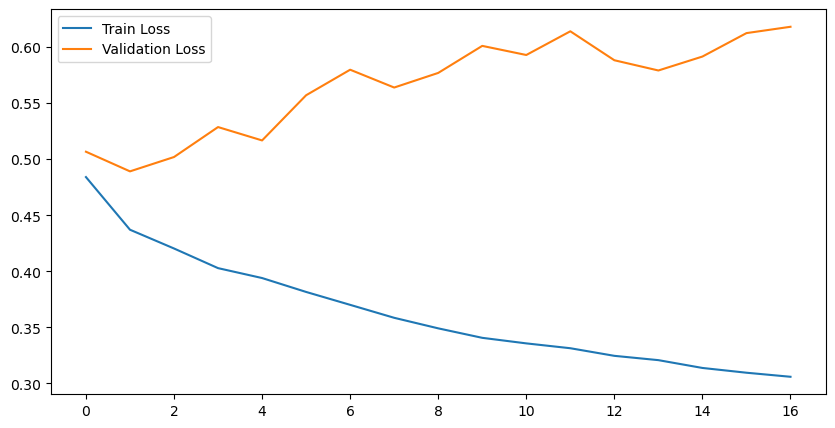

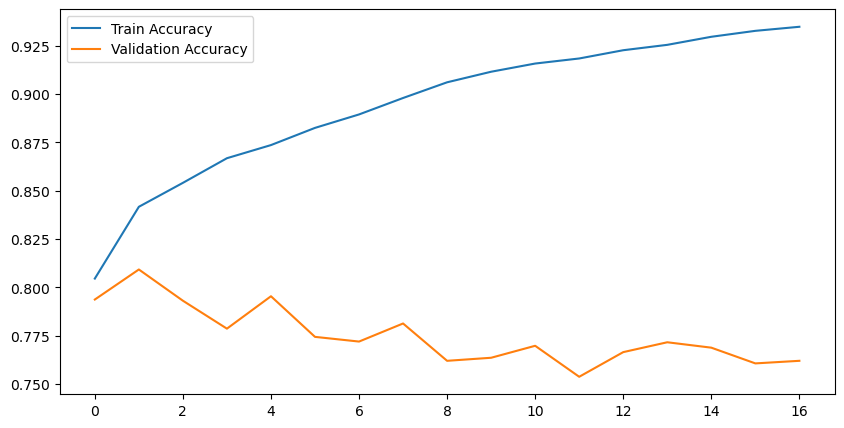

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history_train_loss,label="Train Loss")
plt.plot(history_val_loss,label="Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history_train_acc,label="Train Accuracy")
plt.plot(history_val_acc,label="Validation Accuracy")
plt.legend()
plt.show()

## Saving model to S3

In [26]:
import boto3
os.makedirs("saved_models/efficientnet_b3_binary", exist_ok=True)

torch.save(
    {"model_state_dict": model.state_dict(),
     "optimizer_state_dict": optimizer.state_dict(),
     "scheduler_state_dict": scheduler.state_dict(),
     "best_accuracy": best_accuracy, "epochs": EPOCHS}, "saved_models/efficientnet_b3_binary/efficientnet_b3_binary_checkpoint.pth")

In [27]:
BUCKET_NAME = "skin-lesion-data-bucket"
MODEL_FOLDER = "saved_models/efficientnet_b3_binary"
s3 = boto3.client("s3")
local_file = "saved_models/efficientnet_b3_binary/efficientnet_b3_binary_checkpoint.pth"
s3_key = f"{MODEL_FOLDER}/efficientnet_b3_binary_checkpoint.pth"

s3.upload_file(local_file, BUCKET_NAME, s3_key)

print(f"Uploaded -> s3://{BUCKET_NAME}/{s3_key}")

Uploaded -> s3://skin-lesion-data-bucket/saved_models/efficientnet_b3_binary/efficientnet_b3_binary_checkpoint.pth
